# **Improving Candidate Placement Success Rate**

## **Business Problem**
Placed wants to improve placement conversion by understanding which factors truly influence student employability and hiring success.

## **Objective**
The goal of this analysis is to identify the academic, technical, practical, cognitive, and professional factors that drive placement success and provide actionable business recommendations.

# **North Star Metric**

## **Placement Success Rate**

Placement Success Rate = Number of Students Placed ÷ Total Students

This is the primary business metric because it reflects how effectively Placed converts students into successful hires.

To improve this metric, we break it into smaller actionable components.

In [ ]:
!pip install gdown

In [ ]:
import gdown
import pandas as pd
import numpy as np

In [ ]:
file_id = "1M7aRHzeR7HKjMz-kImOTRuA5S0VUE3Pp"

download_url = f"https://drive.google.com/uc?id={file_id}"

In [ ]:
output_file = "Placed_dataset.csv"

In [ ]:
gdown.download(download_url, output_file, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1M7aRHzeR7HKjMz-kImOTRuA5S0VUE3Pp
From (redirected): https://drive.google.com/uc?id=1M7aRHzeR7HKjMz-kImOTRuA5S0VUE3Pp&confirm=t&uuid=68cf3786-6e97-4e02-a245-a4f6e2d3d28d
To: /content/Placed_dataset.csv
100%|██████████| 181M/181M [00:01<00:00, 144MB/s]


'Placed_dataset.csv'

In [ ]:
df = pd.read_csv(output_file)

# **Dataset Understanding**


In [ ]:
df.head(5)

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,branch,college_tier,python_skill,c++_skill,...,certifications,coding_contest_rating,teamwork,leadership,problem_solving,time_management,gender,city_tier,family_income,placed
0,23,7.94,3,84.656624,81.551017,54.282095,CSE,2,9,8,...,0,756.826630,5,9,9,2,Female,1,7.849912,1
1,24,7.46,2,90.663809,71.742919,61.844316,IT,3,7,6,...,1,1008.725810,3,1,4,8,Female,2,8.621398,1
2,22,7.17,2,84.895718,87.972353,80.510087,CSE,1,3,2,...,2,1053.419286,6,0,6,5,Female,3,4.046578,0
3,24,8.27,2,69.347246,72.739454,88.699314,ECE,1,2,5,...,3,1194.295018,9,1,9,9,Female,2,8.676290,1
4,24,8.34,2,74.225862,45.648440,77.383406,CSE,2,3,1,...,1,1182.628600,9,0,7,7,Male,3,6.996345,0


In [ ]:
df.shape

(1000000, 30)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 30 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   age                    1000000 non-null  int64  
 1   cgpa                   1000000 non-null  float64
 2   backlogs               1000000 non-null  int64  
 3   attendance             1000000 non-null  float64
 4   tenth_percentage       1000000 non-null  float64
 5   twelfth_percentage     1000000 non-null  float64
 6   branch                 1000000 non-null  object 
 7   college_tier           1000000 non-null  int64  
 8   python_skill           1000000 non-null  int64  
 9   c++_skill              1000000 non-null  int64  
 10  java_skill             1000000 non-null  int64  
 11  ml_skill               1000000 non-null  int64  
 12  web_dev_skill          1000000 non-null  int64  
 13  communication_skill    1000000 non-null  int64  
 14  aptitude_score     

In [ ]:
df.describe()

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,college_tier,python_skill,c++_skill,java_skill,...,hackathons,certifications,coding_contest_rating,teamwork,leadership,problem_solving,time_management,city_tier,family_income,placed
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,22.500194,7.499208,1.200309,79.923544,77.956957,74.915697,2.000118,4.503381,4.503944,4.501439,...,0.998496,1.997867,1200.028210,4.499140,4.496364,4.501241,4.497319,2.000799,8.007746,0.500159
std,1.707373,0.988203,1.094803,9.801409,9.871486,11.785236,0.816557,2.873744,2.871332,2.871802,...,0.999361,1.416061,399.867290,2.870049,2.872036,2.872764,2.873606,0.816499,2.973567,0.500000
min,20.000000,5.000000,0.000000,40.000000,40.000000,40.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,21.000000,6.830000,0.000000,73.249464,71.267875,66.889926,1.000000,2.000000,2.000000,2.000000,...,0.000000,1.000000,929.025586,2.000000,2.000000,2.000000,2.000000,1.000000,5.972419,0.000000
50%,23.000000,7.500000,1.000000,80.003117,78.010477,74.987332,2.000000,5.000000,5.000000,5.000000,...,1.000000,2.000000,1199.794028,5.000000,4.000000,5.000000,4.000000,2.000000,7.998021,1.000000
75%,24.000000,8.170000,2.000000,86.750697,84.744644,83.094789,3.000000,7.000000,7.000000,7.000000,...,2.000000,3.000000,1470.289975,7.000000,7.000000,7.000000,7.000000,3.000000,10.022507,1.000000
max,25.000000,10.000000,10.000000,100.000000,100.000000,100.000000,3.000000,9.000000,9.000000,9.000000,...,8.000000,12.000000,3000.000000,9.000000,9.000000,9.000000,9.000000,3.000000,23.480764,1.000000


The summary statistics provide an overview of the numerical features, including their central tendency and distribution. Initial observations suggest variation across academic performance, technical skills, and placement-related attributes.

# **Data Quality Checks**

## **Hypothesis**
The dataset is expected to have minimal missing or duplicate values because placement datasets are generally collected through structured institutional processes.

In [ ]:
df.isnull().sum()

,0
age,0
cgpa,0
backlogs,0
attendance,0
tenth_percentage,0
twelfth_percentage,0
branch,0
college_tier,0
python_skill,0
c++_skill,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## **Observation**
The dataset contains no missing values and no significant duplicate records.


# **Outlier Detection**

## **Hypothesis**
The dataset is expected to contain minimal outliers because most student-related metrics naturally fall within realistic ranges.

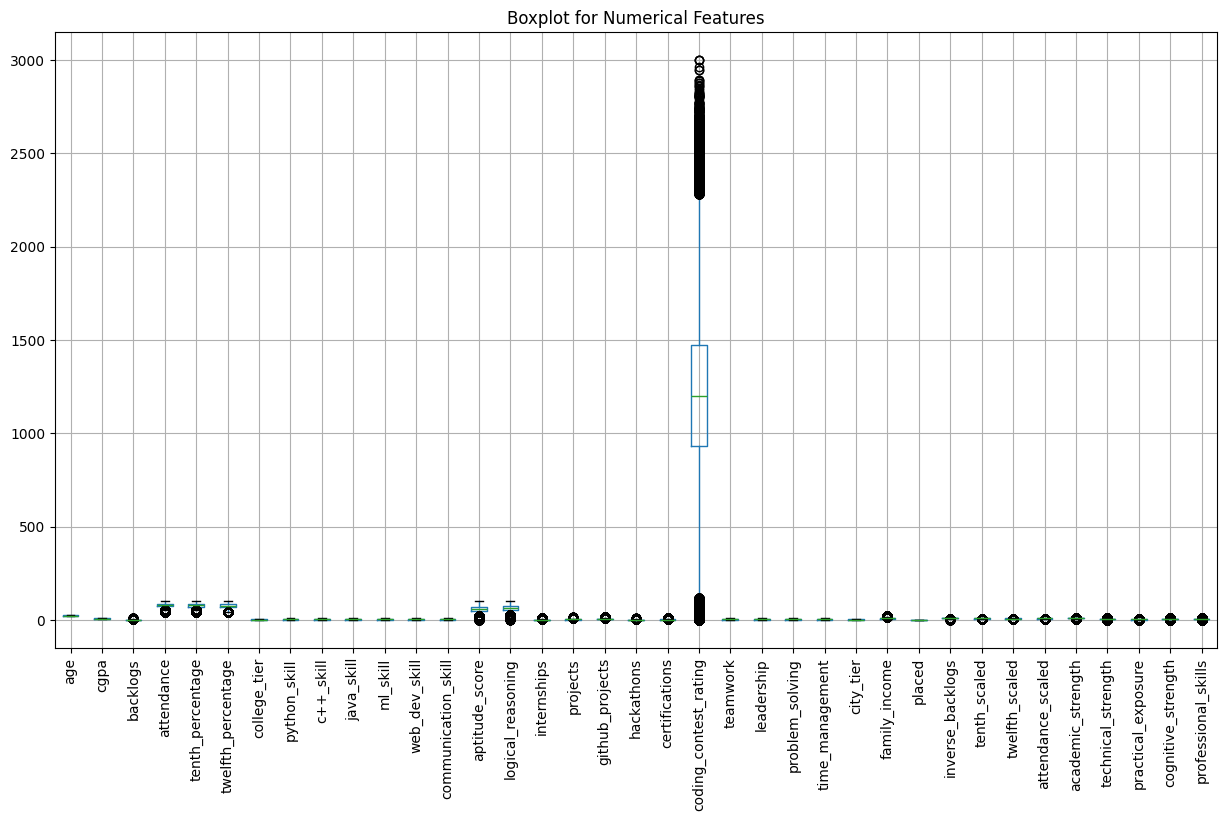

In [189]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15,8))
df[numerical_cols].boxplot(rot=90)
plt.title("Boxplot for Numerical Features")
plt.show()

## **Observation**

- Visible outliers are mainly observed in the coding conrtest rating feature, which is expected because coding platforms naturally have a small number of exceptionally high-performing students.

- Most other numerical features fall within realistic and stable ranges without significant extreme deviations.

- The larger scale of coding contest ratings compared to other features visually exaggerates the appearance of outliers in the combined boxplot.

## **Separating Placed and Non-Placed Students**

The dataset was divided into placed and non-placed students to analyze patterns and compare characteristics between both groups.

In [ ]:
placed_students = df[df['placed'] == 1]

non_placed_students = df[df['placed'] == 0]

In [ ]:
placed_students.shape

(500159, 30)

In [ ]:
non_placed_students.shape

(499841, 30)

## **Analysis of Placed and Non-Placed Students**

The dataset was separated into placed and non-placed students in order to compare patterns between both groups.

The shape of the data shows that:
- **500,159** students were placed
- **499,841** students were not placed

This indicates that the dataset is nearly balanced, with an almost equal distribution of placed and non-placed students.

# **Univariate Analysis**

Univariate analysis was conducted to understand the distribution and characteristics of individual variables in the dataset. The analysis focuses on academic performance, technical skills, experience metrics, and soft skills to identify general trends among students.

In [ ]:
academic_features = [
    'cgpa',
    'attendance',
    'tenth_percentage',
    'twelfth_percentage',
    'backlogs'
]

df[academic_features].describe()

,cgpa,attendance,tenth_percentage,twelfth_percentage,backlogs
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,7.499208,79.923544,77.956957,74.915697,1.200309
std,0.988203,9.801409,9.871486,11.785236,1.094803
min,5.000000,40.000000,40.000000,40.000000,0.000000
25%,6.830000,73.249464,71.267875,66.889926,0.000000
50%,7.500000,80.003117,78.010477,74.987332,1.000000
75%,8.170000,86.750697,84.744644,83.094789,2.000000
max,10.000000,100.000000,100.000000,100.000000,10.000000


### **Hypothesis**
Students with stronger academic consistency are expected to demonstrate better placement outcomes.

array([[<Axes: title={'center': 'cgpa'}>,
        <Axes: title={'center': 'attendance'}>],
       [<Axes: title={'center': 'tenth_percentage'}>,
        <Axes: title={'center': 'twelfth_percentage'}>],
       [<Axes: title={'center': 'backlogs'}>, <Axes: >]], dtype=object)

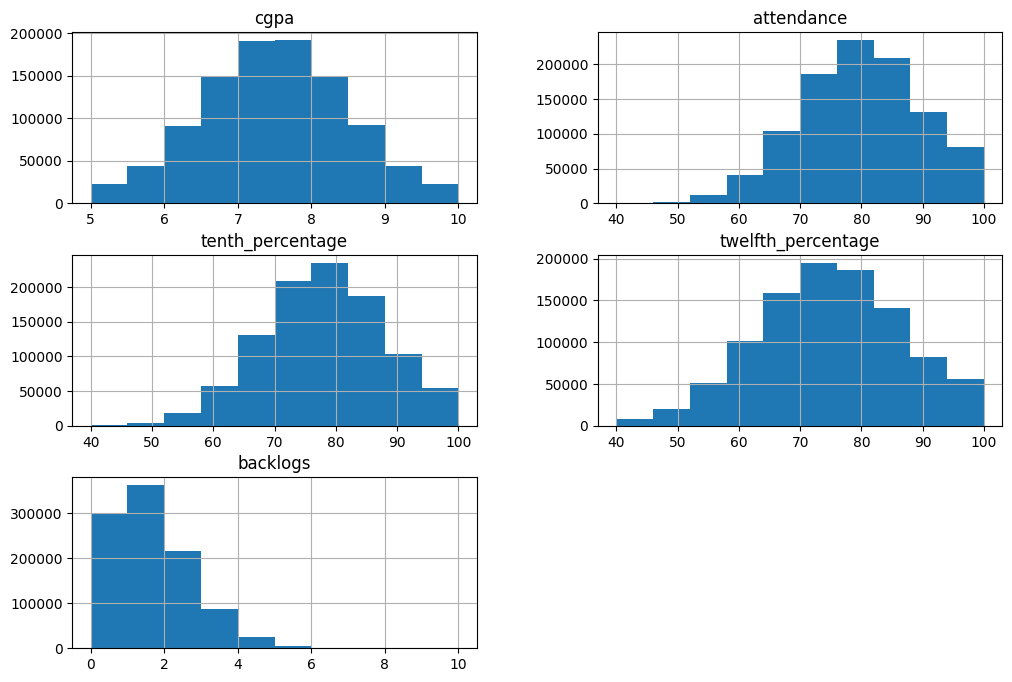

In [ ]:
df[academic_features].hist(figsize=(12,8))

### **Observations**

- Most students demonstrate moderate to strong academic performance, with CGPA generally concentrated between 7 and 8 and backlog counts remaining relatively low across the dataset.

## **Univariate Analysis of Technical Skills**

Technical skill-related features were analyzed to understand student proficiency across various programming and development domains. The analysis focuses on identifying the distribution and variation of technical competencies among students.

In [ ]:
technical_features = [
    'python_skill',
    'c++_skill',
    'java_skill',
    'ml_skill',
    'web_dev_skill'
]

df[technical_features].describe()

,python_skill,c++_skill,java_skill,ml_skill,web_dev_skill
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,4.503381,4.503944,4.501439,4.497754,4.500293
std,2.873744,2.871332,2.871802,2.873953,2.871247
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000
50%,5.000000,5.000000,5.000000,4.000000,5.000000
75%,7.000000,7.000000,7.000000,7.000000,7.000000
max,9.000000,9.000000,9.000000,9.000000,9.000000


### **Hypothesis**
Students with stronger technical skills are expected to achieve higher placement success, even when academic performance is moderate.

array([[<Axes: title={'center': 'python_skill'}>,
        <Axes: title={'center': 'c++_skill'}>],
       [<Axes: title={'center': 'java_skill'}>,
        <Axes: title={'center': 'ml_skill'}>],
       [<Axes: title={'center': 'web_dev_skill'}>, <Axes: >]],
      dtype=object)

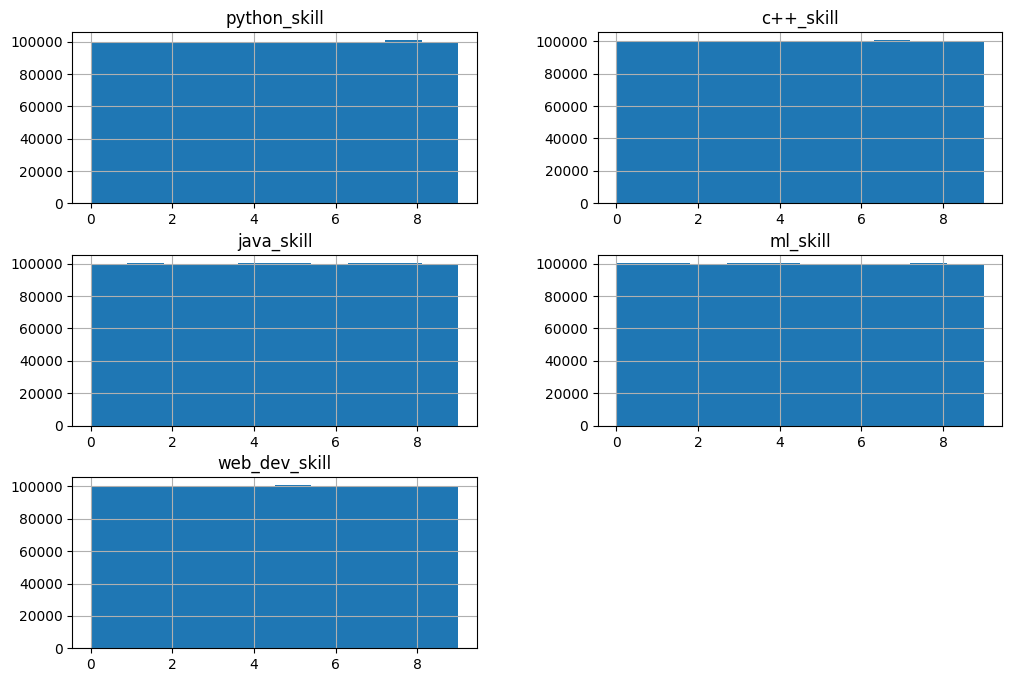

In [ ]:
df[technical_features].hist(figsize=(12,8))

### **Observations**

- Students demonstrate varied technical skill levels across programming and development domains, indicating noticeable differences in technical readiness.

## **Univariate Analysis of Practical Experience Features**

Practical experience-related features were analyzed to understand student exposure to real-world projects, internships, coding activities, and certifications.

In [ ]:
practical_features = [
    'internships',
    'projects',
    'github_projects',
    'hackathons',
    'certifications'
]

df[practical_features].describe()

,internships,projects,github_projects,hackathons,certifications
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,1.498702,3.001866,4.000183,0.998496,1.997867
std,1.224711,1.732494,2.000483,0.999361,1.416061
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,3.000000,0.000000,1.000000
50%,1.000000,3.000000,4.000000,1.000000,2.000000
75%,2.000000,4.000000,5.000000,2.000000,3.000000
max,11.000000,15.000000,16.000000,8.000000,12.000000


### **Hypothesis**
Students with stronger practical exposure through internships, projects, and certifications are expected to demonstrate higher placement readiness.

array([[<Axes: title={'center': 'internships'}>,
        <Axes: title={'center': 'projects'}>],
       [<Axes: title={'center': 'github_projects'}>,
        <Axes: title={'center': 'hackathons'}>],
       [<Axes: title={'center': 'certifications'}>, <Axes: >]],
      dtype=object)

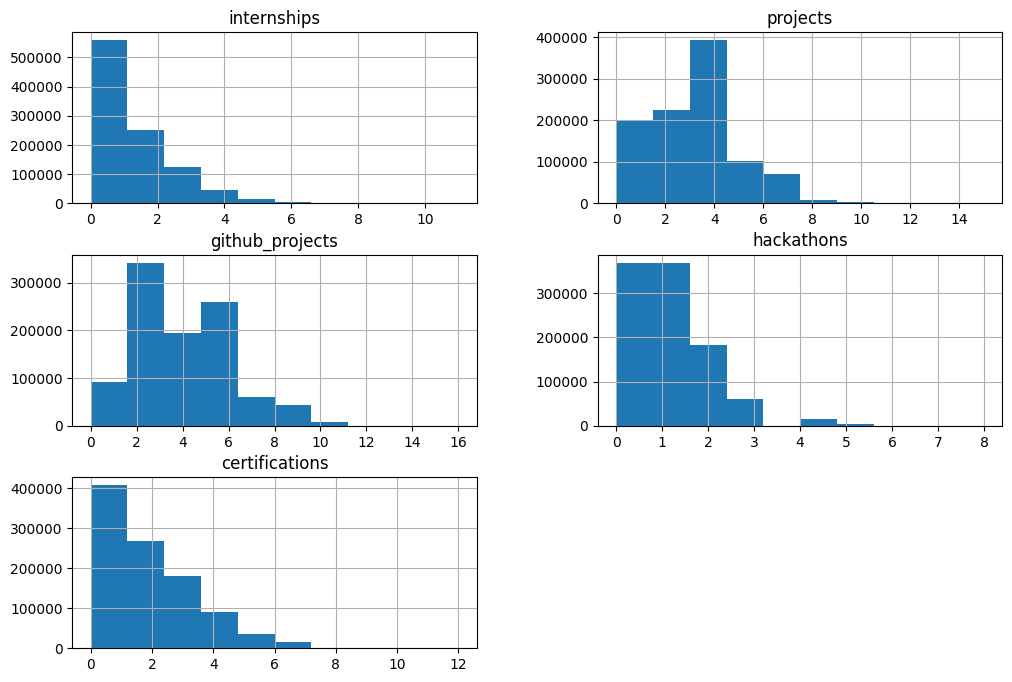

In [ ]:
df[practical_features].hist(figsize=(12,8))

### **Observations**

- Practical exposure varies noticeably across students, with most candidates having limited internships, certifications, and hackathon participation while project involvement remains comparatively broader.

## **Univariate Analysis of Soft Skills**

Soft skill-related features were analyzed to understand communication ability, teamwork, leadership, problem-solving, and time management capabilities among students.

In [ ]:
softskill_features = [
    'communication_skill',
    'teamwork',
    'leadership',
    'problem_solving',
    'time_management'
]

df[softskill_features].describe()

,communication_skill,teamwork,leadership,problem_solving,time_management
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,4.503571,4.499140,4.496364,4.501241,4.497319
std,2.873887,2.870049,2.872036,2.872764,2.873606
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000
50%,5.000000,5.000000,4.000000,5.000000,4.000000
75%,7.000000,7.000000,7.000000,7.000000,7.000000
max,9.000000,9.000000,9.000000,9.000000,9.000000


### **Hypothesis**
Students with stronger communication and interpersonal skills are expected to perform better during interviews and hiring processes.

array([[<Axes: title={'center': 'communication_skill'}>,
        <Axes: title={'center': 'teamwork'}>],
       [<Axes: title={'center': 'leadership'}>,
        <Axes: title={'center': 'problem_solving'}>],
       [<Axes: title={'center': 'time_management'}>, <Axes: >]],
      dtype=object)

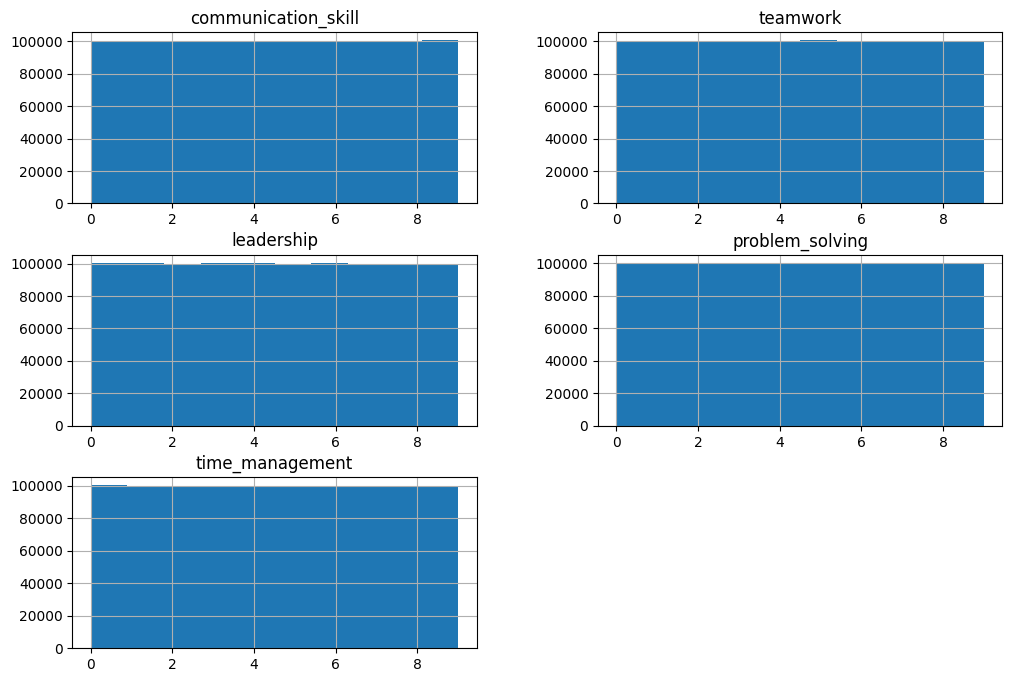

In [ ]:
df[softskill_features].hist(figsize=(12,8))

### **Observations**

- Soft skill distributions remain relatively balanced across students, indicating moderate variation in communication, teamwork, leadership, and professional readiness.

## **Univariate Analysis of Cognitive Skills**

Cognitive skill-related features were analyzed to understand student aptitude, logical reasoning, and analytical ability distributions across the dataset.

In [ ]:
cognitive_features = [
    'aptitude_score',
    'logical_reasoning'
]

df[cognitive_features].describe()

,aptitude_score,logical_reasoning
count,1000000.000000,1000000.000000
mean,59.970438,64.962900
std,14.940624,14.888112
min,0.000000,0.000000
25%,49.873558,54.863133
50%,59.976927,64.987698
75%,70.081367,75.143965
max,100.000000,100.000000


### **Hypothesis**
Students with stronger aptitude and logical reasoning abilities are expected to perform better in placement assessments and technical screening rounds.

array([[<Axes: title={'center': 'aptitude_score'}>,
        <Axes: title={'center': 'logical_reasoning'}>]], dtype=object)

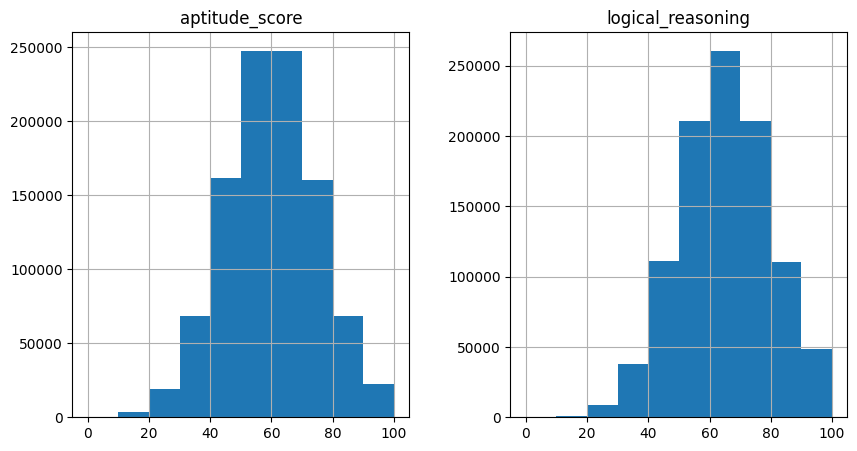

In [ ]:
df[cognitive_features].hist(figsize=(10,5))

### **Observations**

- Cognitive skill distributions remain relatively stable across students, with most candidates demonstrating moderate-to-high aptitude and logical reasoning scores.

# **From Distribution Analysis to Relationship Analysis**

1. While the univariate analysis helped understand individual feature
distributions, it did not reveal how strongly different variables relate to placement outcomes.

2. To quantify the relationships between employability dimensions and placement success more systematically, correlation analysis was performed.


# **Correlation Analysis with Placement**

Correlation analysis is performed to identify numerical features that show the strongest linear relationship with placement status.

- Positive correlation indicates that higher feature values are associated with higher placement likelihood.
- Negative correlation indicates that higher feature values are associated with lower placement likelihood.

This analysis helps identify the most influential factors affecting placement outcomes.

### **Hypothesis**

Technical skills, practical exposure, and cognitive abilities are expected to show stronger positive relationships with placement outcomes compared to purely academic metrics.

In [ ]:
correlation_with_placement = (
    df.corr(numeric_only=True)['placed']
    .sort_values(ascending=False)
)

correlation_with_placement

,placed
placed,1.000000
java_skill,0.140398
python_skill,0.139277
c++_skill,0.138423
web_dev_skill,0.138010
ml_skill,0.137330
cgpa,0.115080
internships,0.093855
aptitude_score,0.086057
logical_reasoning,0.085608


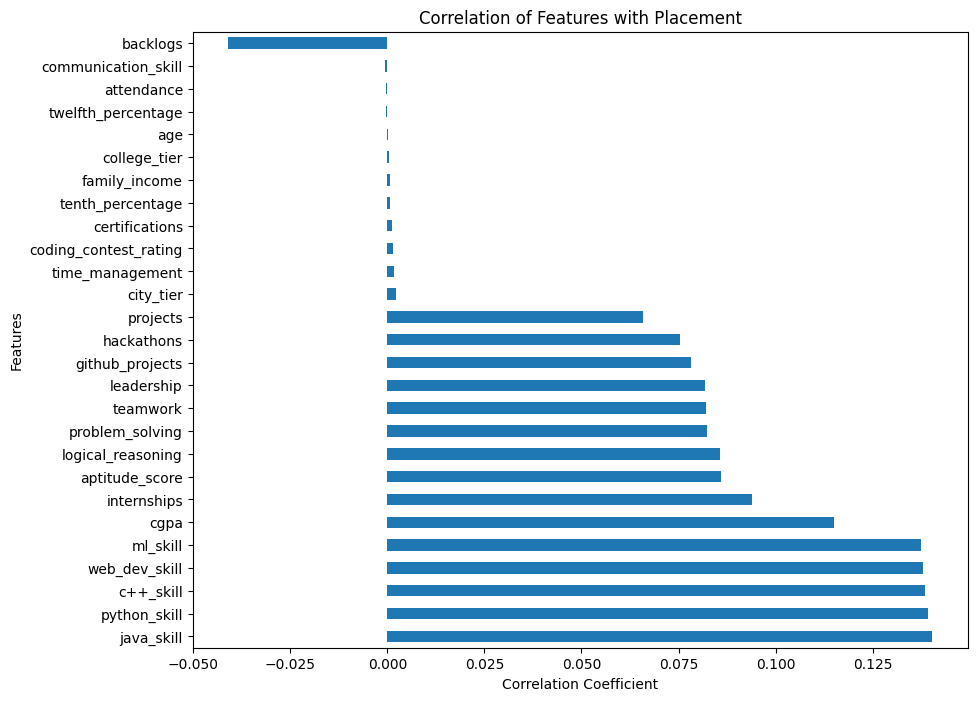

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

correlation_with_placement.drop('placed').plot(kind='barh')

plt.title('Correlation of Features with Placement')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

plt.show()

### **Key Insights**

- Technical skill variables such as Python, Java, C++, ML, and Web Development demonstrate some of the strongest positive relationships with placement outcomes.

- Practical exposure features including internships, projects, hackathons, and certifications also show meaningful positive correlations, reinforcing the importance of real-world experience.

- Academic metrics such as CGPA show moderate positive relationships with placement, while backlog count displays a slight negative relationship.

- Variables including age, attendance, and family income exhibit very weak correlations with placement outcomes, suggesting limited direct influence on employability.

# **Comparing Placement Outcomes Across Students**

1. The correlation analysis identified several variables showing meaningful relationships with placement outcomes, particularly across technical, practical, and cognitive dimensions.

2. To further validate these patterns visually and compare placed versus non-placed students directly, bivariate analysis was performed.


# **Bivariate Analysis**

Bivariate analysis was conducted to examine how key features differ between placed and non-placed students. Related variables with similar behavioral patterns were grouped together to avoid redundant analysis while maintaining focus on the most influential placement factors.

### **Hypothesis**

Placed students are expected to demonstrate stronger overall profiles across technical skills, practical exposure, cognitive ability, and professional competencies compared to non-placed students.

In [ ]:
comparison = pd.DataFrame({
    'Placed': placed_students.mean(numeric_only=True),
    'Not Placed': non_placed_students.mean(numeric_only=True)
})

comparison

,Placed,Not Placed
age,22.500525,22.499863
cgpa,7.612894,7.385450
backlogs,1.155361,1.245286
attendance,79.920548,79.926542
tenth_percentage,77.964159,77.949751
twelfth_percentage,74.912205,74.919191
college_tier,2.000552,1.999684
python_skill,4.903499,4.103009
c++_skill,4.901275,4.106360
java_skill,4.904504,4.098117


### **Observations**

- Placed students consistently show higher average values across technical skills, practical exposure, cognitive ability, and professional skills compared to non-placed students.

- Technical skill variables such as Python, Java, C++, ML, and Web Development show some of the clearest differences, with placed students averaging close to 4.9 while non-placed students remain near 4.1.

- Practical exposure indicators including internships, projects, certifications, and hackathons also remain noticeably higher among placed students, suggesting stronger industry readiness.

- Academic metrics such as CGPA and backlog count show comparatively smaller differences between both groups, indicating that academics alone may not fully explain placement success.

# **Selective Visualization of Key Features**

- The comparative analysis already highlights that many related variables follow similar behavioral patterns between placed and non-placed students.

- To avoid repetitive visualizations, only the most representative and placement-influential features were selected for detailed boxplot analysis.

- The selected features demonstrate stronger practical significance, clearer group separation, or higher relevance to placement outcomes.

### **Selected Features**
- CGPA
- Backlogs
- Internships
- Python Skill
- Aptitude Score

In [ ]:
!pip install seaborn

import seaborn as sns


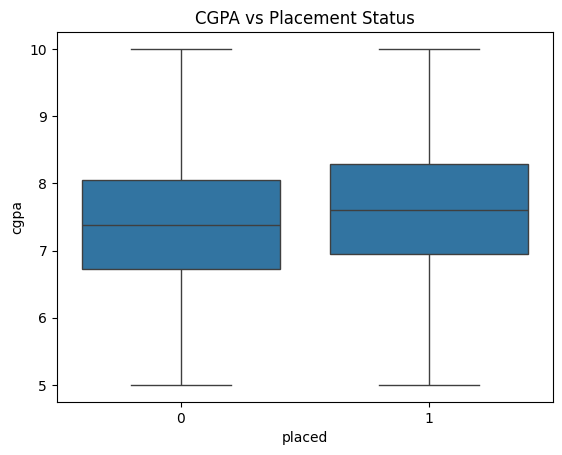

In [ ]:
sns.boxplot(x='placed', y='cgpa', data=df)

plt.title('CGPA vs Placement Status')

plt.show()

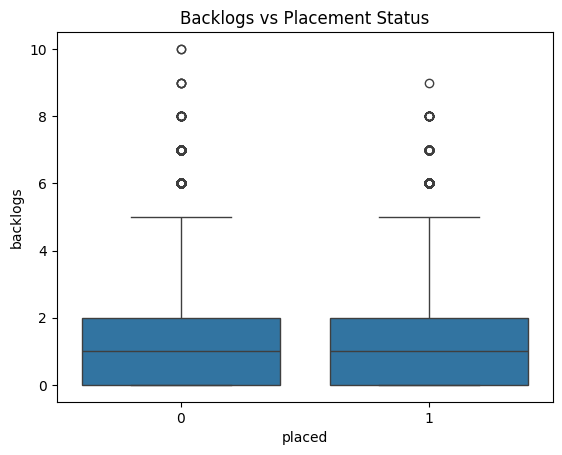

In [ ]:
sns.boxplot(x='placed', y='backlogs', data=df)

plt.title('Backlogs vs Placement Status')

plt.show()

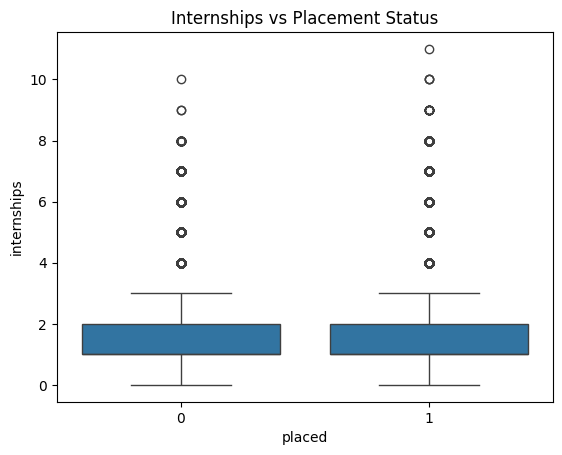

In [ ]:
sns.boxplot(x='placed', y='internships', data=df)

plt.title('Internships vs Placement Status')

plt.show()

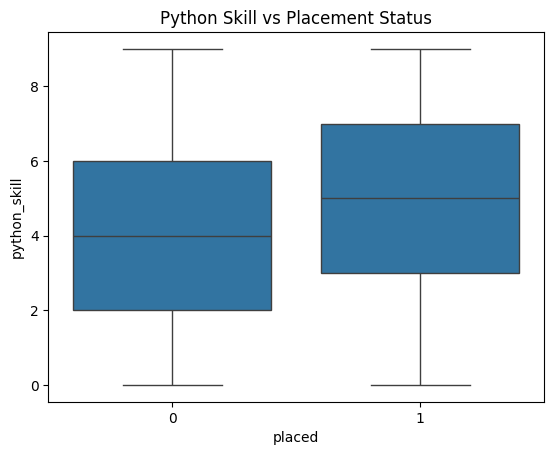

In [ ]:
sns.boxplot(x='placed', y='python_skill', data=df)

plt.title('Python Skill vs Placement Status')

plt.show()

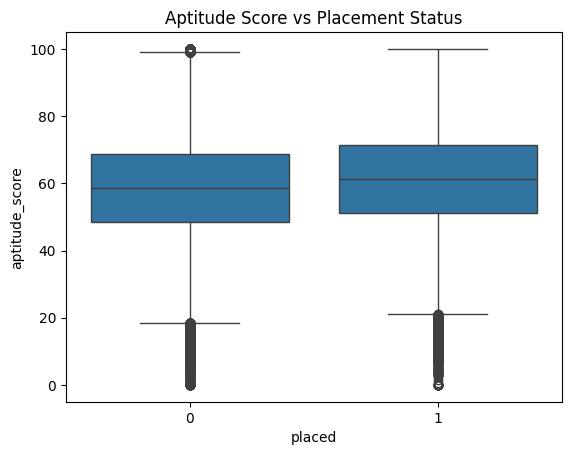

In [ ]:
sns.boxplot(x='placed', y='aptitude_score', data=df)

plt.title('Aptitude Score vs Placement Status')

plt.show()

### **Observations from Boxplot Analysis**

- Placed students generally demonstrate higher technical, academic, cognitive, and practical experience scores compared to non-placed students.

- Technical skill variables, particularly Python proficiency, show noticeably stronger values among placed students, highlighting the importance of technical capability in placement success.

- Students with higher aptitude and reasoning scores tend to achieve better placement outcomes, suggesting that cognitive ability positively contributes to employability.

- Internship participation and lower backlog counts are associated with comparatively better placement outcomes, indicating the value of practical exposure and academic consistency.

# **Building Multidimensional Employability Features**

1. The bivariate analysis revealed that multiple related variables collectively influence placement outcomes rather than acting independently.

2. To better capture broader employability behavior, higher-level multidimensional features were engineered by grouping related variables together.


# **Feature Engineering**

- Feature engineering was performed to create broader employability indicators by grouping related variables together.

- Composite features were created for:
  - academic strength
  - technical proficiency
  - practical exposure
  - cognitive ability
  - professional skills

- Backlog scores were inversely transformed since higher backlog counts negatively affect academic readiness.

- This approach improves interpretability and helps represent overall student employability more effectively.

## **Creating Inverse Backlog Score**

Backlog counts negatively affect placement readiness. Therefore, backlog values were inversely transformed so that lower backlogs contribute positively toward overall academic strength.

In [ ]:
df['inverse_backlogs'] = 10 - df['backlogs']

## **Scaling Academic Features**

Academic percentage-based variables such as 10th percentage, 12th percentage, and attendance were scaled down to maintain consistency with CGPA and backlog-related features during feature aggregation.

In [ ]:
df['tenth_scaled'] = df['tenth_percentage'] / 10

df['twelfth_scaled'] = df['twelfth_percentage'] / 10

df['attendance_scaled'] = df['attendance'] / 10

## **Creating Academic Strength Feature**

An academic strength score was created by combining CGPA, academic percentages, attendance, and inverse backlog scores to represent overall academic consistency and performance.

In [ ]:
df['academic_strength'] = (
    df['cgpa'] +
    df['tenth_scaled'] +
    df['twelfth_scaled'] +
    df['attendance_scaled'] +
    df['inverse_backlogs']
) / 5

## **Creating Technical Strength Feature**

A technical strength score was created by combining Python, Java, C++, Machine Learning, and Web Development skills to represent overall technical competency across multiple domains.

In [ ]:
df['technical_strength'] = (
    df['python_skill'] +
    df['java_skill'] +
    df['c++_skill'] +
    df['ml_skill'] +
    df['web_dev_skill']
) / 5

## **Creating Practical Exposure Feature**

A practical exposure score was created by combining internships, projects, GitHub projects, hackathons, and certifications to represent overall hands-on and real-world experience.

In [ ]:
df['practical_exposure'] = (
    df['internships'] +
    df['projects'] +
    df['github_projects'] +
    df['hackathons'] +
    df['certifications']
) / 5

## **Creating Cognitive Strength Feature**

A cognitive strength score was created using aptitude, logical reasoning, and problem-solving ability to represent overall analytical and reasoning capability.

In [ ]:
df['cognitive_strength'] = ((df['aptitude_score'] / 10 + df['logical_reasoning'] / 10 + df['problem_solving']) / 3).round(2)


## **Creating Professional Skills Feature**

A professional skills score was created by combining communication, teamwork, leadership, and time management skills to represent overall workplace readiness and interpersonal capability.

In [ ]:
df['professional_skills'] = (
    df['communication_skill'] +
    df['teamwork'] +
    df['leadership'] +
    df['time_management']
) / 4

## **Verifying Engineered Features**

The newly created engineered features were reviewed to ensure that the transformed variables were generated successfully and represent the intended student performance dimensions.

In [ ]:
df[[
    'academic_strength',
    'technical_strength',
    'practical_exposure',
    'cognitive_strength',
    'professional_skills'
]].head()

,academic_strength,technical_strength,practical_exposure,cognitive_strength,professional_skills
0,7.397795,7.8,1.2,6.95,5.75
1,7.577021,7.2,2.8,6.53,4.00
2,8.101563,2.4,2.4,7.21,3.50
3,7.869720,4.6,2.8,7.28,6.25
4,7.213154,4.4,1.8,6.64,5.50


# **Multivariate Analysis**

Multivariate analysis was performed to examine how broader student performance dimensions interact together in influencing placement outcomes.

Instead of analyzing variables independently, this analysis focuses on understanding whether strength in one area can compensate for weaker performance in another area.

## **Academic Strength vs Technical Strength and Placement**

This analysis examines how academic performance and technical proficiency jointly influence placement outcomes.

The objective is to understand whether strong technical skills can compensate for weaker academic performance during placements.

### **Hypothesis**

Strong technical proficiency is expected to significantly improve placement outcomes across all academic categories.

Additionally, students with moderate academic performance but strong technical skills are expected to outperform students with strong academics but weak technical proficiency.

In [ ]:
df['academic_level'] = pd.qcut(
    df['academic_strength'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df['technical_level'] = pd.qcut(
    df['technical_strength'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

## **Placement Rate Across Academic and Technical Levels**

Placement rates were calculated across different combinations of academic and technical performance levels to identify interaction patterns between these dimensions.

In [ ]:
academic_technical_analysis = pd.pivot_table(
    df,
    values='placed',
    index='academic_level',
    columns='technical_level',
    aggfunc='mean'
)

academic_technical_analysis

/tmp/ipykernel_3542/2385198131.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  academic_technical_analysis = pd.pivot_table(


technical_level,Low,Medium,High
academic_level,,,
Low,0.304982,0.471840,0.640852
Medium,0.337956,0.513910,0.676416
High,0.374985,0.555374,0.710718


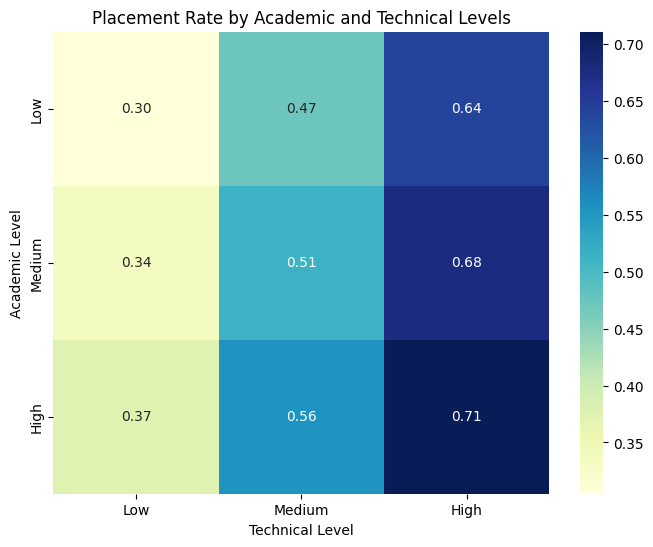

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    academic_technical_analysis,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Placement Rate by Academic and Technical Levels')

plt.xlabel('Technical Level')

plt.ylabel('Academic Level')

plt.show()

### **Key Insights**

- Technical proficiency demonstrates a significantly stronger influence on placement outcomes than academic performance across all academic categories.

- Students with low academic strength but high technical proficiency achieve nearly ~64% placement rates, compared to only ~30% among students weak in both dimensions, highlighting the strong compensating effect of technical capability.

- Students with high academic performance but low technical skills achieve only ~37% placement rates, which remains substantially lower than students with weaker academics but stronger technical proficiency (~64%).

- The highest placement success (~71%) is observed among students combining both strong academics and high technical proficiency, indicating that balanced multidimensional strength produces the strongest employability outcomes.

# **Technical Strength vs Practical Exposure and Placement**

This analysis examines how technical proficiency and practical exposure jointly influence placement outcomes.

The objective is to understand whether practical experience enhances the impact of technical skills during placements.

### **Hypothesis**

Students with stronger technical proficiency and higher practical exposure are expected to achieve the highest placement success rates.

Additionally, practical exposure is expected to strengthen placement outcomes significantly when combined with technical competency.

In [ ]:
df['technical_level'] = pd.qcut(
    df['technical_strength'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df['practical_level'] = pd.qcut(
    df['practical_exposure'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# **Placement Rate Across Technical and Practical Levels**

Placement rates were calculated across different combinations of technical skill levels and practical exposure levels to identify interaction patterns between these dimensions.

In [ ]:
technical_practical_analysis = pd.pivot_table(
    df,
    values='placed',
    index='technical_level',
    columns='practical_level',
    aggfunc='mean'
)

technical_practical_analysis

/tmp/ipykernel_3542/3167254002.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  technical_practical_analysis = pd.pivot_table(


practical_level,Low,Medium,High
technical_level,,,
Low,0.275471,0.346369,0.426688
Medium,0.442868,0.523096,0.608820
High,0.613270,0.688271,0.755460


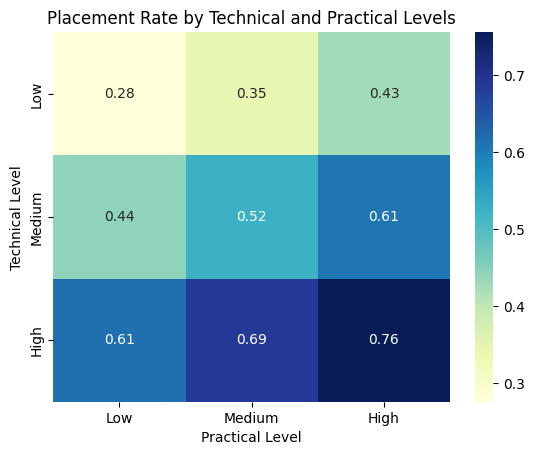

In [ ]:
sns.heatmap(
    technical_practical_analysis,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Placement Rate by Technical and Practical Levels')

plt.xlabel('Practical Level')

plt.ylabel('Technical Level')

plt.show()

### **Key Insights**

- Technical proficiency continues to emerge as the strongest employability driver, with placement rates increasing consistently across all practical exposure categories as technical capability improves.

- Students with low technical skills and low practical exposure achieve only ~28% placement rates, while students with similarly weak technical profiles but high practical exposure improve to ~43%, showing that practical experience positively contributes to employability.

- Students with high technical proficiency but low practical exposure still achieve approximately ~61% placement rates, reinforcing technical competency as the foundational placement driver.

- The highest placement success (~76%) is observed among students combining both strong technical proficiency and high practical exposure, highlighting the value of balanced industry-ready profiles.

# **Cognitive Ability vs Technical Strength and Placement**

This analysis examines how cognitive ability and technical proficiency jointly influence placement outcomes.

The objective is to understand whether strong reasoning and problem-solving ability can support employability alongside technical skills.

### **Hypothesis**

Students with stronger cognitive ability and technical proficiency are expected to achieve higher placement success rates.

Additionally, strong reasoning and problem-solving ability may partially support employability when technical proficiency is moderate.

In [ ]:
df['cognitive_level'] = pd.qcut(
    df['cognitive_strength'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df['technical_level'] = pd.qcut(
    df['technical_strength'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# **Placement Rate Across Cognitive and Technical Levels**

Placement rates were calculated across different combinations of cognitive ability levels and technical proficiency levels to identify interaction patterns between these dimensions.

In [ ]:
cognitive_technical_analysis = pd.pivot_table(
    df,
    values='placed',
    index='cognitive_level',
    columns='technical_level',
    aggfunc='mean'
)

cognitive_technical_analysis

/tmp/ipykernel_3542/1328654651.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cognitive_technical_analysis = pd.pivot_table(


technical_level,Low,Medium,High
cognitive_level,,,
Low,0.267844,0.430447,0.601919
Medium,0.337091,0.514690,0.679815
High,0.413041,0.596719,0.747419


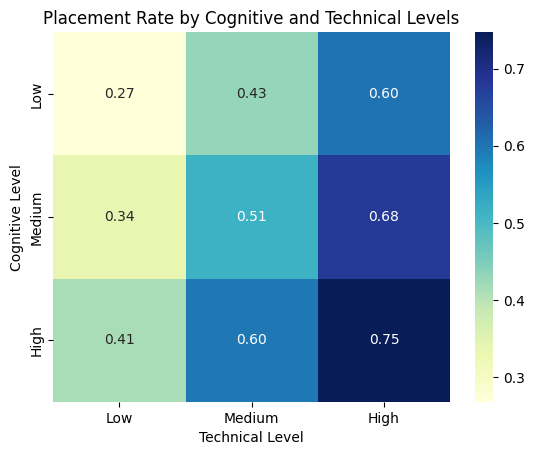

In [ ]:
sns.heatmap(
    cognitive_technical_analysis,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Placement Rate by Cognitive and Technical Levels')

plt.xlabel('Technical Level')

plt.ylabel('Cognitive Level')

plt.show()

### **Key Insights**

- Technical proficiency continues to demonstrate the strongest influence on placement outcomes, with placement rates increasing steadily across all cognitive categories as technical capability improves.

- Students with low cognitive ability and low technical skills achieve only ~27% placement rates, while students with similarly weak cognitive profiles but high technical proficiency improve significantly to ~60%.

- Students with high cognitive ability but low technical proficiency achieve only ~ 41% placement rates, which remains lower than students with weaker cognitive ability but stronger technical capability (~60%), reinforcing the dominant role of technical skills in employability.

- The highest placement success (~75%) is observed among students combining both strong cognitive ability and high technical proficiency, highlighting the value of balanced analytical and technical strength.

# **Professional Skills vs Technical Strength and Placement**

This analysis examines how professional skills and technical proficiency jointly influence placement outcomes.

The objective is to understand whether strong professional competencies can enhance employability alongside technical skills.

### **Hypothesis**

Students with stronger professional skills and technical proficiency are expected to achieve higher placement success rates.

Additionally, professional competencies such as communication, teamwork, and leadership are expected to enhance employability when combined with strong technical capability.

In [ ]:
df['professional_level'] = pd.qcut(
    df['professional_skills'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df['technical_level'] = pd.qcut(
    df['technical_strength'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# **Placement Rate Across Professional and Technical Levels**

Placement rates were calculated across different combinations of professional skill levels and technical proficiency levels to identify interaction patterns between these dimensions.

In [ ]:
professional_technical_analysis = pd.pivot_table(
    df,
    values='placed',
    index='professional_level',
    columns='technical_level',
    aggfunc='mean'
)

professional_technical_analysis

/tmp/ipykernel_3542/322125096.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  professional_technical_analysis = pd.pivot_table(


technical_level,Low,Medium,High
professional_level,,,
Low,0.294454,0.464093,0.632701
Medium,0.341527,0.518169,0.681139
High,0.390531,0.567920,0.721740


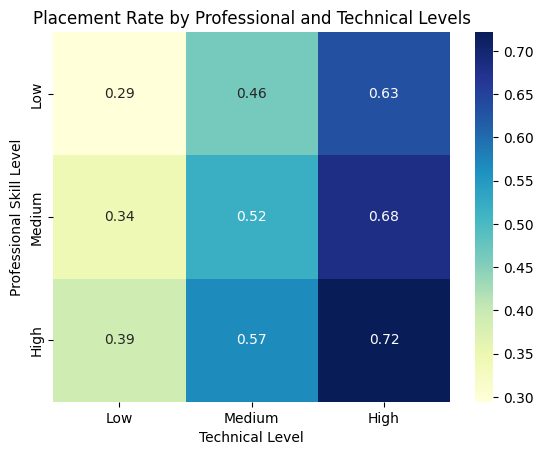

In [ ]:
sns.heatmap(
    professional_technical_analysis,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Placement Rate by Professional and Technical Levels')

plt.xlabel('Technical Level')

plt.ylabel('Professional Skill Level')

plt.show()

### **Key Insights**

- Technical proficiency continues to emerge as the strongest placement driver across all professional skill categories, with placement rates increasing consistently as technical capability improves.

- Students with low professional skills and low technical proficiency achieve only ~29% placement rates, while students with similarly weak professional profiles but high technical proficiency improve significantly to ~63%.

- Students with high professional skills but low technical proficiency achieve only ~ 39% placement rates, which remains substantially lower than students with weaker professional skills but stronger technical capability (~63%), reinforcing the dominant influence of technical proficiency.

- The highest placement success (~72%) is observed among students combining both strong professional skills and high technical proficiency, highlighting the value of balanced technical and interpersonal readiness.

# **Full Employability Profile Analysis**

This section extends the multivariate interaction analysis by combining all major employability dimensions together to identify recurring candidate profile structures.

The objective is to examine how different combinations of:

- academic strength
- technical capability
- practical exposure
- professional skills
- cognitive ability


### **Hypothesis**

- Students demonstrating balanced strengths across technical capability, practical exposure, cognitive ability, professional skills, and academics are expected to achieve the highest placement success rates.

- Additionally, profiles weak across multiple employability dimensions are expected to consistently demonstrate lower placement outcomes.

- The analysis also aims to evaluate whether strong technical and employability-oriented capabilities can compensate for comparatively weaker academic performance.


In [ ]:
dimensions = [
    'academic_strength',
    'technical_strength',
    'practical_exposure',
    'professional_skills',
    'cognitive_strength'
]

for col in dimensions:

    level_name = col + '_level'

    df[level_name] = pd.qcut(
        df[col],
        q=3,
        labels=['Low', 'Medium', 'High']
    )

# **Creating Multidimensional Employability Profiles**

All employability dimensions were combined to create complete candidate profile structures representing overall student readiness across academics, technical capability, practical exposure, professional skills, and cognitive ability.

This helps identify recurring high-performing and low-performing employability patterns across placements.

# **Understanding Employability Profile Distribution**

Before identifying archetypes, the distribution of students across employability profiles was examined to ensure sufficient representation across profile combinations.

This helps avoid conclusions based on statistically weak or low-volume candidate structures.

In [ ]:
profile_analysis = df.groupby([

    'academic_strength_level',
    'technical_strength_level',
    'practical_exposure_level',
    'professional_skills_level',
    'cognitive_strength_level'

]).agg(

    placement_rate=('placed', 'mean'),
    student_count=('placed', 'count')

).reset_index()

profile_analysis

/tmp/ipykernel_3542/44680259.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile_analysis = df.groupby([


,academic_strength_level,technical_strength_level,practical_exposure_level,professional_skills_level,cognitive_strength_level,placement_rate,student_count
0,Low,Low,Low,Low,Low,0.151943,5739
1,Low,Low,Low,Low,Medium,0.205953,5846
2,Low,Low,Low,Low,High,0.260328,5785
3,Low,Low,Low,Medium,Low,0.187069,6527
4,Low,Low,Low,Medium,Medium,0.244046,6634
...,...,...,...,...,...,...,...
238,High,High,High,Medium,Medium,0.799947,3809
239,High,High,High,Medium,High,0.841881,3763
240,High,High,High,High,Low,0.787004,2770
241,High,High,High,High,Medium,0.828230,2678


# **Understanding Top Employability Profiles**

- The highest-performing employability profiles were examined to identify recurring multidimensional skill combinations associated with strong placement outcomes.

- This helps uncover dominant high-performing candidate structures and the employability dimensions most strongly linked to placement success.

In [ ]:
top_profiles = profile_analysis.sort_values(
    by='placement_rate',
    ascending=False
)

top_profiles.head(20)

,academic_strength_level,technical_strength_level,practical_exposure_level,professional_skills_level,cognitive_strength_level,placement_rate,student_count
242,High,High,High,High,High,0.865443,2616
161,Medium,High,High,High,High,0.852073,2677
239,High,High,High,Medium,High,0.841881,3763
233,High,High,Medium,High,High,0.829825,3373
80,Low,High,High,High,High,0.828463,2635
241,High,High,High,High,Medium,0.828230,2678
152,Medium,High,Medium,High,High,0.814539,3219
236,High,High,High,Low,High,0.812996,3278
158,Medium,High,High,Medium,High,0.811511,3666
238,High,High,High,Medium,Medium,0.799947,3809


# **Identifying Weakest Employability Profiles**

Low-performing employability profiles were analyzed to identify recurring placement-risk structures and common employability gaps.

This helps uncover vulnerable candidate combinations associated with consistently lower placement outcomes.

In [ ]:
bottom_profiles = profile_analysis.sort_values(
    by='placement_rate',
    ascending=True
)

bottom_profiles.head(20)

,academic_strength_level,technical_strength_level,practical_exposure_level,professional_skills_level,cognitive_strength_level,placement_rate,student_count
0,Low,Low,Low,Low,Low,0.151943,5739
81,Medium,Low,Low,Low,Low,0.179664,5655
3,Low,Low,Low,Medium,Low,0.187069,6527
162,High,Low,Low,Low,Low,0.195097,5792
9,Low,Low,Medium,Low,Low,0.200876,4794
1,Low,Low,Low,Low,Medium,0.205953,5846
84,Medium,Low,Low,Medium,Low,0.211244,6670
6,Low,Low,Low,High,Low,0.221989,4766
82,Medium,Low,Low,Low,Medium,0.231496,5715
90,Medium,Low,Medium,Low,Low,0.231539,4699


# **Constructing Employability Archetypes**

1. The multidimensional interaction analysis revealed several recurring high-performing and low-performing employability structures.

2. To simplify these recurring patterns into interpretable candidate categories, employability archetypes were constructed.

# **Employability Archetype Analysis**

- This section groups recurring multidimensional employability profiles into broader candidate archetypes based on common skill patterns and placement behavior.

- The analysis helps identify dominant high-performing and placement-risk candidate structures across multiple employability dimensions.

# **Employability Archetype 1 — Elite Employability Profiles**

This archetype represents students demonstrating consistently strong performance across nearly all employability dimensions.

These profiles typically combine:

- strong technical capability
- strong practical exposure
- strong professional skills
- strong cognitive ability
- solid academic performance

In [ ]:
elite_profiles = profile_analysis[

    (profile_analysis['technical_strength_level'] == 'High') &
    (profile_analysis['practical_exposure_level'] == 'High') &
    (profile_analysis['professional_skills_level'] == 'High') &
    (profile_analysis['cognitive_strength_level'] == 'High')

].sort_values(
    by='placement_rate',
    ascending=False
)

elite_profiles.head(10)

,academic_strength_level,technical_strength_level,practical_exposure_level,professional_skills_level,cognitive_strength_level,placement_rate,student_count
242,High,High,High,High,High,0.865443,2616
161,Medium,High,High,High,High,0.852073,2677
80,Low,High,High,High,High,0.828463,2635


# **Observations**

- Elite employability profiles consistently achieved the highest placement outcomes, with placement rates ranging approximately from 82% to 87%.

- One of the strongest findings observed was that students with low academic strength but high technical, practical, professional, and cognitive capability still achieved placement rates above 82%.

- Overall, the findings suggest that multidimensional employability skills can significantly compensate for weaker academic performance.

# **Employability Archetype 2 — Technical-Core Achievers**

This archetype represents students who achieve strong placement outcomes despite weaker academic performance.

These profiles are characterized by:

- high technical capability
- moderate or strong practical exposure
- weaker academic strength


In [ ]:
technical_core_profiles = profile_analysis[

    (profile_analysis['academic_strength_level'] == 'Low') &
    (profile_analysis['technical_strength_level'] == 'High')

].sort_values(
    by='placement_rate',
    ascending=False
)

technical_core_profiles.head(10)

,academic_strength_level,technical_strength_level,practical_exposure_level,professional_skills_level,cognitive_strength_level,placement_rate,student_count
80,Low,High,High,High,High,0.828463,2635
77,Low,High,High,Medium,High,0.794431,3663
79,Low,High,High,High,Medium,0.782529,2736
71,Low,High,Medium,High,High,0.766262,3213
74,Low,High,High,Low,High,0.759237,3356
68,Low,High,Medium,Medium,High,0.737962,4465
76,Low,High,High,Medium,Medium,0.719116,3667
70,Low,High,Medium,High,Medium,0.713083,3325
62,Low,High,Low,High,High,0.708571,3850
78,Low,High,High,High,Low,0.700755,2650


# **Observations**

- Technical-Core Achiever profiles demonstrated that students with low academic strength but high technical capability consistently achieved placement rates between 70% and 83%.

- Placement outcomes improved further when technical capability was supported by stronger practical exposure and cognitive ability.

- Overall, technical capability emerged as a dominant employability factor capable of substantially improving placement success despite weaker academic performance.

# **Employability Archetype 3 — Industry-Ready Practitioners**

This archetype represents students demonstrating strong practical readiness and workplace-oriented skills.

These profiles typically combine:

- strong practical exposure
- strong professional skills
- moderate to strong technical capability

In [ ]:
industry_ready_profiles = profile_analysis[

    (profile_analysis['practical_exposure_level'] == 'High') &
    (profile_analysis['professional_skills_level'] == 'High')&
    (profile_analysis['technical_strength_level'] == 'Medium')

].sort_values(
    by='placement_rate',
    ascending=False
)

industry_ready_profiles.head(10)

,academic_strength_level,technical_strength_level,practical_exposure_level,professional_skills_level,cognitive_strength_level,placement_rate,student_count
215,High,Medium,High,High,High,0.770666,2359
134,Medium,Medium,High,High,High,0.730205,2387
214,High,Medium,High,High,Medium,0.715281,2441
53,Low,Medium,High,High,High,0.694994,2377
133,Medium,Medium,High,High,Medium,0.649918,2428
213,High,Medium,High,High,Low,0.636063,2418
52,Low,Medium,High,High,Medium,0.625705,2482
132,Medium,Medium,High,High,Low,0.588065,2413
51,Low,Medium,High,High,Low,0.550749,2404


# **Observations**

- Industry-Ready Practitioner profiles achieved placement rates ranging approximately from 55% to 77% through strong practical exposure and professional readiness.

- Students with high practical exposure and strong professional skills achieved comparatively strong placement outcomes even with only moderate technical capability.

- Overall, practical exposure and professional readiness emerged as strong employability amplifiers supporting placement success.

# **Employability Archetype 4 — Academic-Oriented Profiles**

This archetype represents students with strong academic performance but comparatively weaker employability-oriented skill dimensions.

These profiles typically contain:

- strong academic performance
- weaker technical capability
- limited practical exposure

In [ ]:
academic_oriented_profiles = profile_analysis[

    (profile_analysis['academic_strength_level'] == 'High') &
    (profile_analysis['technical_strength_level'] == 'Low')

].sort_values(
    by='placement_rate',
    ascending=False
)

academic_oriented_profiles.head(10)

,academic_strength_level,technical_strength_level,practical_exposure_level,professional_skills_level,cognitive_strength_level,placement_rate,student_count
188,High,Low,High,High,High,0.605602,3106
185,High,Low,High,Medium,High,0.555504,4270
187,High,Low,High,High,Medium,0.526786,3136
179,High,Low,Medium,High,High,0.516343,3916
182,High,Low,High,Low,High,0.501735,3747
184,High,Low,High,Medium,Medium,0.476583,4484
186,High,Low,High,High,Low,0.464744,3120
176,High,Low,Medium,Medium,High,0.464399,5379
170,High,Low,Low,High,High,0.434672,4730
178,High,Low,Medium,High,Medium,0.433145,3904


# **Observations**

- Academic-Oriented profiles achieved placement rates ranging approximately from 43% to 61%, which remained noticeably lower than elite employability profiles.

- Even among academically strong students, weaker technical capability consistently limited placement performance.

- Overall, the findings suggest that academic excellence alone is insufficient to consistently produce strong placement outcomes without employability-oriented skill support.

# **Employability Archetype 5 — High-Risk Employability Profiles**

This archetype represents vulnerable employability structures associated with consistently weak placement outcomes.

These profiles typically contain:

- weak technical capability
- weak practical exposure
- weaker cognitive and professional skill structures


In [ ]:
high_risk_profiles = profile_analysis[

    (profile_analysis['technical_strength_level'] == 'Low') &
    (profile_analysis['practical_exposure_level'] == 'Low')

].sort_values(
    by='placement_rate',
    ascending=True
)

high_risk_profiles.head(10)

,academic_strength_level,technical_strength_level,practical_exposure_level,professional_skills_level,cognitive_strength_level,placement_rate,student_count
0,Low,Low,Low,Low,Low,0.151943,5739
81,Medium,Low,Low,Low,Low,0.179664,5655
3,Low,Low,Low,Medium,Low,0.187069,6527
162,High,Low,Low,Low,Low,0.195097,5792
1,Low,Low,Low,Low,Medium,0.205953,5846
84,Medium,Low,Low,Medium,Low,0.211244,6670
6,Low,Low,Low,High,Low,0.221989,4766
82,Medium,Low,Low,Low,Medium,0.231496,5715
4,Low,Low,Low,Medium,Medium,0.244046,6634
165,High,Low,Low,Medium,Low,0.246344,6564


# **Observations**

- High-Risk employability profiles demonstrated the weakest placement outcomes, with placement rates remaining approximately between 15% and 25%.

- Profiles containing simultaneously weak technical capability and weak practical exposure consistently showed lower employability performance across recurring candidate structures.

- Overall, weak technical foundations and limited practical readiness emerged as major characteristics associated with lower placement probability.

| **Archetype** | **Placement Range** | **Core Characteristics**|
|---|---|---|
| **Elite Employability Profiles** | 82% – 87% | Strong across nearly all employability dimensions |
| **Technical-Core Achievers** | 70% – 83% | Strong technical capability despite weaker academics |
| **Industry-Ready Practitioners** | 55% – 77% | Strong practical exposure and professional readiness |
| **Academic-Oriented Profiles** | 43% – 61% | Strong academics but weaker technical foundation |
| **High-Risk Employability Profiles** | 15% – 25% | Weak technical and practical foundations across multiple dimensions |

# **Final Analytical Insights**

* Students demonstrating strong technical capability alongside practical exposure, cognitive ability, and professional readiness consistently achieved the strongest placement outcomes.

* One of the strongest findings observed was that students with weaker academic performance but strong multidimensional employability skills still achieved placement rates exceeding 82%.

* In contrast, academically strong profiles without sufficient technical and practical readiness demonstrated comparatively weaker placement performance.

* High-risk employability profiles containing weak technical foundations and limited practical exposure consistently showed the lowest placement rates, generally ranging between 15% and 25%.

* Overall, the analysis suggests that multidimensional employability readiness contributes more strongly to placement success than academic performance alone.


# **Analytical Reflection & Limitations**

One important observation during the analysis was that even the strongest multidimensional employability profiles achieved placement rates of approximately 82%–87% rather than complete placement success.

This raises an important analytical question:

> **What factors influence the remaining unplaced candidates despite strong employability profiles?**

The correlation and multidimensional analyses revealed that several available variables such as:

* college tier
* family income
* branch
* attendance
* age

demonstrated comparatively weak relationships with placement outcomes.

This suggests that additional external or unobserved factors not captured within the dataset may significantly influence final placement decisions.

These may include:

These may include:
- interview performance
- recruiter preferences
- resume quality
- communication during interviews
- company-specific hiring criteria
- career preferences such as higher studies or alternative career paths

Therefore, the analysis should be interpreted as identifying strong employability patterns and placement tendencies rather than absolute placement guarantees for every candidate profile.
